In [1]:
%matplotlib inline
import sys
import os
import time
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

# Model 1 trajectory

In [2]:
# We assume Delta_t = 0.01 for the precomputed M
# For a different Delta t you have to recompute
M = np.array([
    [0.917925, 0.0951229, 0],
    [0.266344, 1.00354, 0],
    [0, 0, 0.973686]
])

def Q_operator(x_scalar, Delta_t):
    # The rotation angle is driven strictly by the first coordinate (x)
    theta = x_scalar * Delta_t
    return np.array([
        [1, 0,             0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta),  np.cos(theta)]
    ])

def lorenz_discrete(x_0, M, Delta_t, N, rand_seed=123):
    """
    Stochastic Lorenz system using the analytic discrete Lie-Trotter map.
    x_{t+1} = M Q(x_t) x_t 
    """
    rng = np.random.default_rng(rand_seed)

    x = np.zeros((N+1, len(x_0)))
    x[0] = x_0

    for t in range(N):
        # Extract the current state vector (shape: 3,)
        x_curr = x[t]
        
        # The rotation relies ONLY on the first coordinate: x_curr[0]
        Q = Q_operator(x_curr[0], Delta_t)
        
        # Q(x_t)x_t (Using @ for clean matrix-vector multiplication)
        nonlinear_update = Q @ x_curr
        
        # M Q(x_t)x_t
        deterministic_update = M @ nonlinear_update

        # Update: Add the precomputed noise for this step!
        x[t+1] = deterministic_update

    return x

## Simulate a long trajectory

In [21]:
Delta_t = 0.01
transient = 1000
N = 50000000 + transient 
x_0 = np.random.normal(0, 1, 3) # We start from a random initial condition and then remove a transient after

# Generate a random seed (or set it manually for reproducibility)
rand_seed = np.random.randint(0, 2**32 - 1)  # Random seed
orbit_discrete = lorenz_discrete(x_0, M, Delta_t, N, rand_seed=123)[transient:]

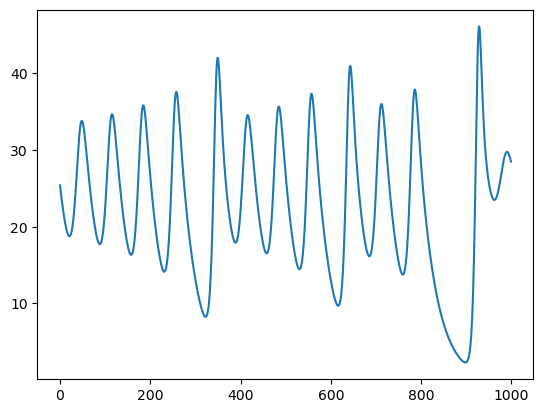

In [7]:
plt.plot(orbit_discrete[0:1000,2])

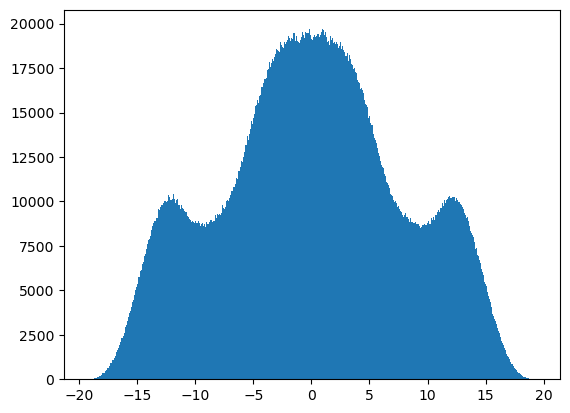

In [8]:
_ = plt.hist(orbit_discrete[:,0],1000)

In [22]:
#np.save('./results/lorenz_long_trajectory.npy',orbit)
np.save('./results/lorenz_long_trajectory_0p01.npy',orbit_discrete)

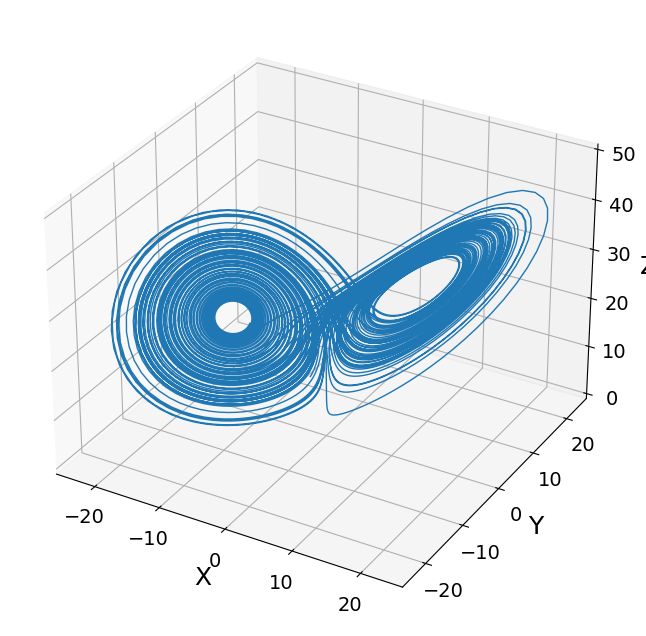

In [26]:
import matplotlib.pyplot as plt

def plotFig(orbit):
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(orbit[:,0], orbit[:,1], orbit[:,2], "-", linewidth=1)
    ax.set_xlabel('X', fontsize=18)
    ax.set_ylabel('Y', fontsize=18)
    ax.set_zlabel('Z', fontsize=18)
    plt.xlim(-25, 25)
    plt.ylim(-25, 25)
    ax.set_zlim(0, 50)  
    ax.tick_params(labelsize=14)
    
    # Save as PDF before showing the plot
    plt.savefig("orbit_plot.pdf", bbox_inches='tight')
    plt.show()

plotFig(orbit_discrete[0:10000])